# 9 模型校准

> **图 9.1**：（左）50 次最大投影运行的反应‑扩散模型输出结果。（右）$\boldsymbol{\eta}=\boldsymbol{\eta}^0$ 以及局部 D‑最优设计下的输出结果（蓝色圆圈）。

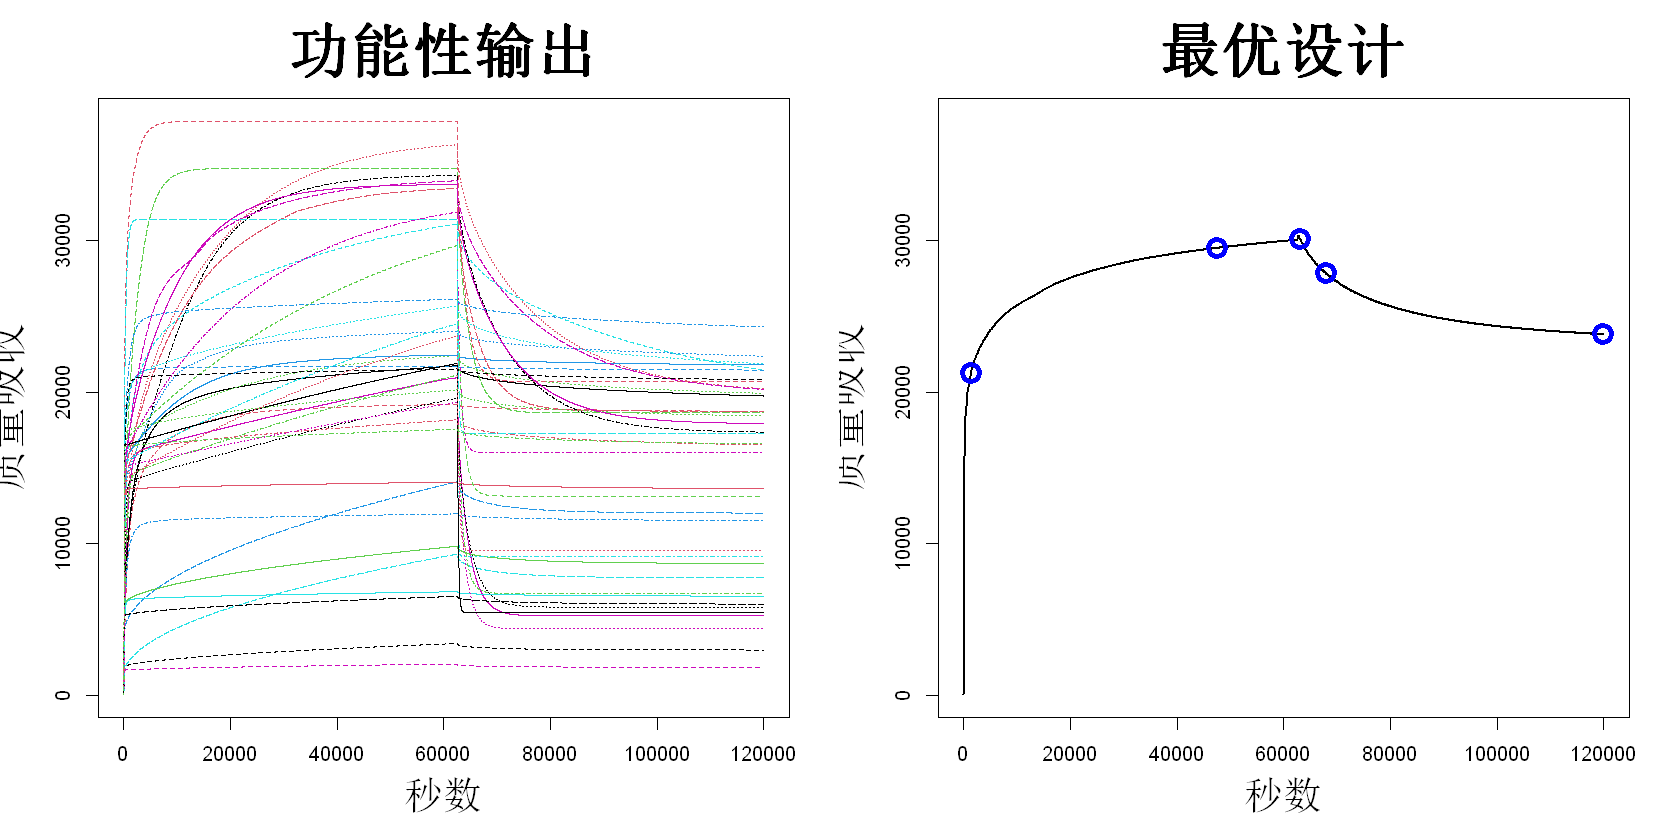

In [1]:
library(rkriging)
library(FNN)
library(ICAOD)
library(numDeriv)
set.seed(1)

if(!file.exists("data/9.1-plot.RData")){
  MP=read.csv(file="data/results.csv",h=TRUE)
  q=5
  D=MP[-51,1:q]
  colnames(D)=NULL
  D[,1]=(log(D[,1])-log(1e-12))/(log(1e-9)-log(1e-12))
  D[,2]=(D[,2]-4e-3)/(5e-3-4e-3)
  D[,3]=(D[,3]-5e-3)/(6e-3-5e-3)
  D[,4]=(D[,4]-500)/(2500-500)
  D[,5]=(log(D[,5])-log(1e-3))/(log(1e1)-log(1e-3))
  N=dim(D)[1]
  q=dim(D)[2]
  pdet=c(seq(0,5000,length.out=2001),seq(5000,120000,length.out=4601)[-1])
  M=length(pdet)
  filename=paste(paste("data/txts/run",sep="",1:50),sep="",".txt")
  Y=matrix(0,nrow=N,ncol=M)
  for(i in 1:N) Y[i,]=read.table(file=filename[i])$V1
  tsamp=seq(0,max(pdet),length=1001)
  Ysamp=Y[,1:1001]
  for(i in 1:N){
    Ysamp[i,]=knn.reg(train=cbind(pdet),test=cbind(tsamp),y=Y[i,],k=1)$pred
  }
  M=length(tsamp)
  tsamp01=tsamp/max(tsamp)
  r.x=function(u,theta.x){
    A=t(t(D1)-u)
    basis.x=function(h) exp(-sum((h/theta.x)^2))
    vec=apply(A,1,basis.x)
    return(vec)
  }
  r.t=function(v,theta.t){
    basis.t=function(h) exp(-abs(h/theta.t))
    vec=basis.t(v-tsamp01)
    return(vec)
  }
  Rtinv.mat=function(rho){
    A=diag(M)
    for(i in 2:(M-1)){
      A[i,i-1]=A[i,i+1]=-rho
      A[i,i]=1+rho^2
    }
    A[1,2]=A[M,M-1]=-rho
    return(A/(1-rho^2))
  }
  ML=function(para){
    theta.x=para[1:q]
    theta.t=para[q+1]
    Rx=apply(D1,1,r.x,theta=theta.x)
    Rxinv=solve(Rx+10^(-6)*diag(N))
    rho=exp(-1/((M-1)*theta.t))
    Rtinv=Rtinv.mat(rho)
    a=c(t((Rxinv%*%rep(1,N))%*%(t(rep(1,M))%*%Rtinv)))
    b=c(t(Rxinv%*%Ysamp%*%Rtinv))
    mu=sum(b)/sum(a)
    sigma2=1/(M*N)*sum((c(t(Ysamp))-mu)*(b-mu*a))
    val=M*N*log(sigma2)+M*determinant(Rx,logarithm=TRUE)$mod[1]+M*N*log(1-rho^2)
    return(val)
  }
  y=apply(Ysamp,1,mean)
  D1=as.matrix(D[,1:q])
  a=Fit.Kriging(D1,y,kernel.parameters=list(type="Gaussian"))
  ini.x=Get.Kriging.Parameters(a)$lengthscale*sqrt(2)
  y=apply(Ysamp,2,mean)
  a=Fit.Kriging(tsamp/max(tsamp),y,kernel.parameters=list(type="Matern12"))
  ini.t=Get.Kriging.Parameters(a)$lengthscale
  ini=c(ini.x,ini.t)
  a.opt=optim(ini,ML,lower=ini/10,upper=ini*10,method="L-BFGS-B")
  theta=a.opt$par
  theta.x=theta[1:q]
  theta.t=theta[q+1]
  Rx=apply(D1,1,r.x,theta=theta.x)
  A=solve(Rx+10^(-6)*diag(N))
  Rxinv=A
  for(i in 1:3) Rxinv=A%*%(diag(N)+10^(-6)*Rxinv)
  rho=exp(-1/((M-1)*theta.t))
  Rtinv=Rtinv.mat(rho)
  a=c(t((Rxinv%*%rep(1,N))%*%(t(rep(1,M))%*%Rtinv)))
  b=c(t(Rxinv%*%Ysamp%*%Rtinv))
  mu=sum(b)/sum(a)
  sigma2=1/(M*N)*sum((c(t(Ysamp))-mu)*(b-mu*a))
  coef=c(b-mu*a)
  COEF=matrix(coef,nrow=N,ncol=M,byrow=TRUE)
  hhat=function(ti,eta) drop(mu+t(r.x(eta,theta.x)%*%COEF%*%r.t(ti,theta.t)))
  fim=function(x,w,param){
    S=matrix(0,nrow=m,ncol=q)
    X=matrix(x,nrow=m)
    for(i in 1:m){
      heta=function(eta) hhat(X[i,],eta)
      S[i,]=grad(heta,x=param)
    }
    M=t(S)%*%diag(w)%*%S
    return(M)
  }
  m=q
  opdes=locally(fimfunc=fim,lx=c(0),ux=c(1),inipars=rep(.5,q),iter=100,k=m,family=gaussian(),ICA.control=list("trace"=FALSE))
  D=matrix(as.numeric(opdes$design[2:(m+1)]),nrow=m,ncol=1)
  w=as.numeric(opdes$design[(m+2):(2*m+1)])
  det(fim(x=c(D),w=w,param=rep(.5,q)))
  DVPI=D
  pred=apply(cbind(tsamp01),1,hhat,eta=rep(.5,q))
  yD=knn.reg(train=cbind(tsamp01),test=cbind(D),y=pred,k=1)$pred
  save(Y,pdet,tsamp,pred,D,yD,theta,file="data/9.1-plot.RData")
} else load("data/9.1-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
matplot(pdet,t(Y),"l",xlab="秒数",ylab="质量吸收",main="功能性输出",cex.lab=2,cex.main=3,cex.axis=1)
plot(tsamp,pred,"l",ylim=range(Y),xlab="秒数",ylab="质量吸收",main="最优设计",cex.lab=2,cex.main=3,cex.axis=1,lwd=2)
points(cbind(D*120000,yD),pch=1,col="blue",cex=2,lwd=4)

> **图 9.2**：（左）双因子指数模型的 8 次局部 D‑最优设计，每个试验点重复两次。（右）对参数不确定性具有鲁棒性的 8 次试验设计。

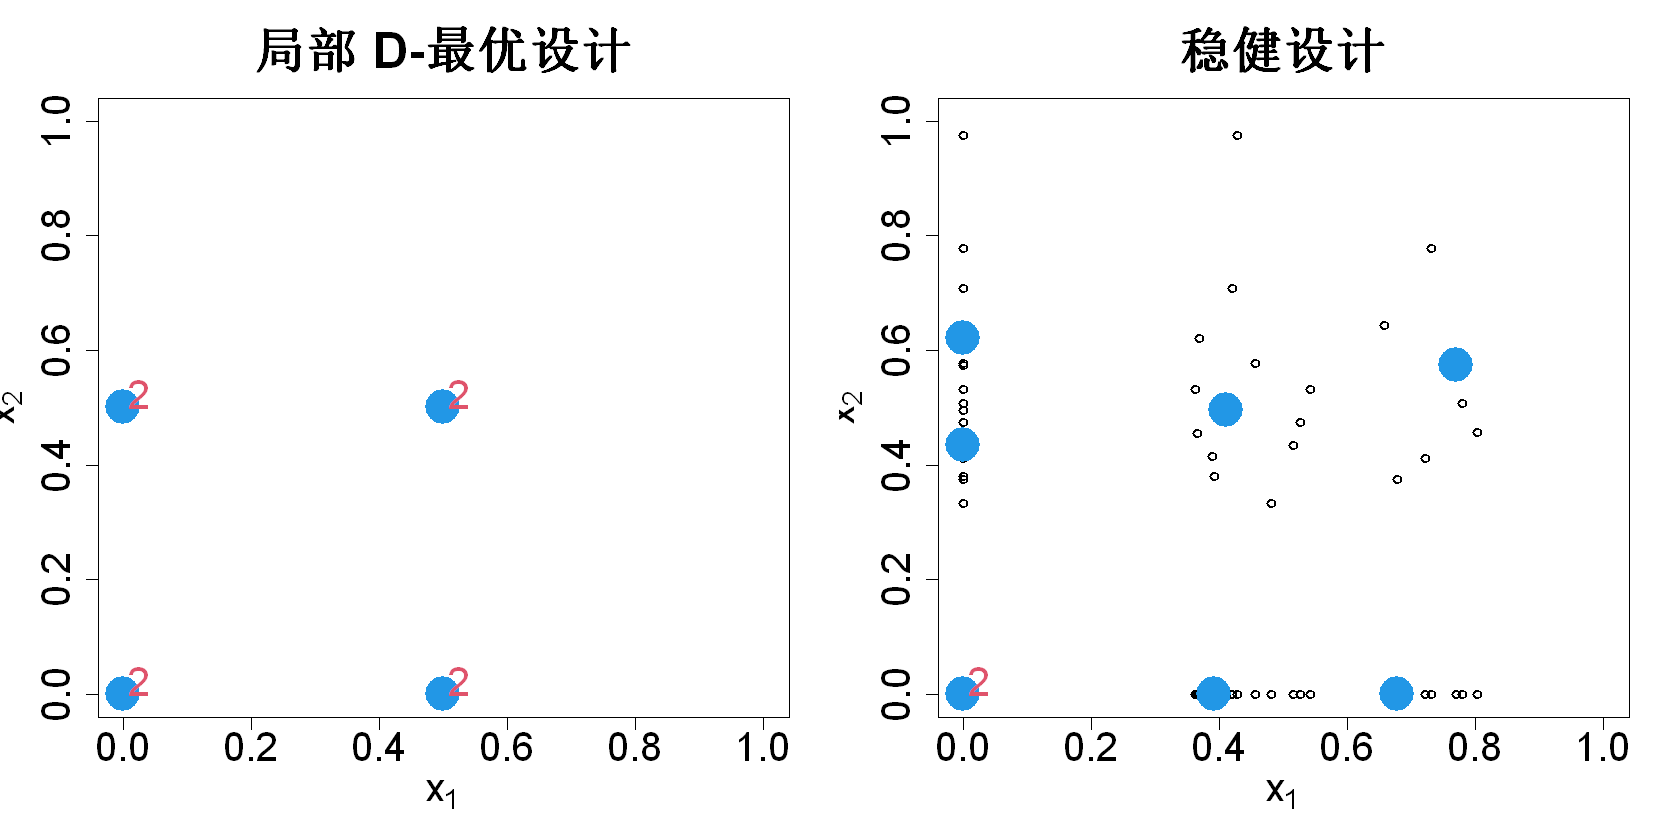

In [2]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/9.2-plot.RData")){
  library(support)
  sp.sample=function(x,n,prob,tol=1e-6,iter.max=10){
    if(is.null(dim(x)))stop("x must be a matrix!")
    N=nrow(x)
    x.dist=as.matrix(dist(x))
    x.measure=c(x.dist%*%prob)
    idx=c(which.min(x.measure))
    if(prob[idx[1]]<1/N)idx[1]=which.max(prob)
    for(i in 2:n){
      measure=x.measure-apply(matrix(x.dist[,idx],ncol=(i-1)),1,sum)/i
      idx=c(idx,which.min(measure))
    }
    edist=2*sum(x.measure[idx])/n-sum(x.dist[idx,idx])/n^2
    iter=0
    while(TRUE){
      iter=iter+1
      for(i in 1:n){
        measure=x.measure-apply(x.dist[,idx[-i]],1,sum)/n
        idx[i]=which.min(measure)
      }
      edist.new=2*sum(x.measure[idx])/n-sum(x.dist[idx,idx])/n^2
      if((edist-edist.new)<tol||iter>iter.max){
        break
      } else {
        edist=edist.new
      }
    }
    return(idx)
  }
  L=matrix(c(0,0,1/2,0,0,1/2,1/2,1/2),ncol=2,byrow=TRUE)
  set.seed(1)
  N=20;p=2
  samp=sp(n=N,p=2,dist.str=c("uniform","normal"))$sp
  samp[,1]=1+2*samp[,1]
  samp[,2]=2+1/2*samp[,2]
  D=NULL
  for(i in 1:20){
    D=rbind(D,matrix(c(0,0,1/samp[i,1],0,0,1/samp[i,2],1/samp[i,1],1/samp[i,2]),ncol=2,byrow=TRUE))
  }
  ind=sp.sample(D,8,prob=rep(.25/20,80))
  save(L,D,ind,file="data/9.2-plot.RData")
}

load("data/9.2-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(L,,pch=16,col=4,cex=4,main="局部 D-最优设计",xlim=c(0,1),ylim=c(0,1),cex.main=2.5,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2)
text(L+.025,"2",col=2,cex=2)
plot(D,xlim=c(0,1),ylim=c(0,1),main="稳健设计",cex.main=2.5,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,lwd=2)
points(D[ind,],pch=16,col=4,cex=4)
text(.025,.025,"2",col=2,cex=2)


> **图 9.3**：物理实验测得的质量吸附量与经校准的反应‑扩散模型预测值。

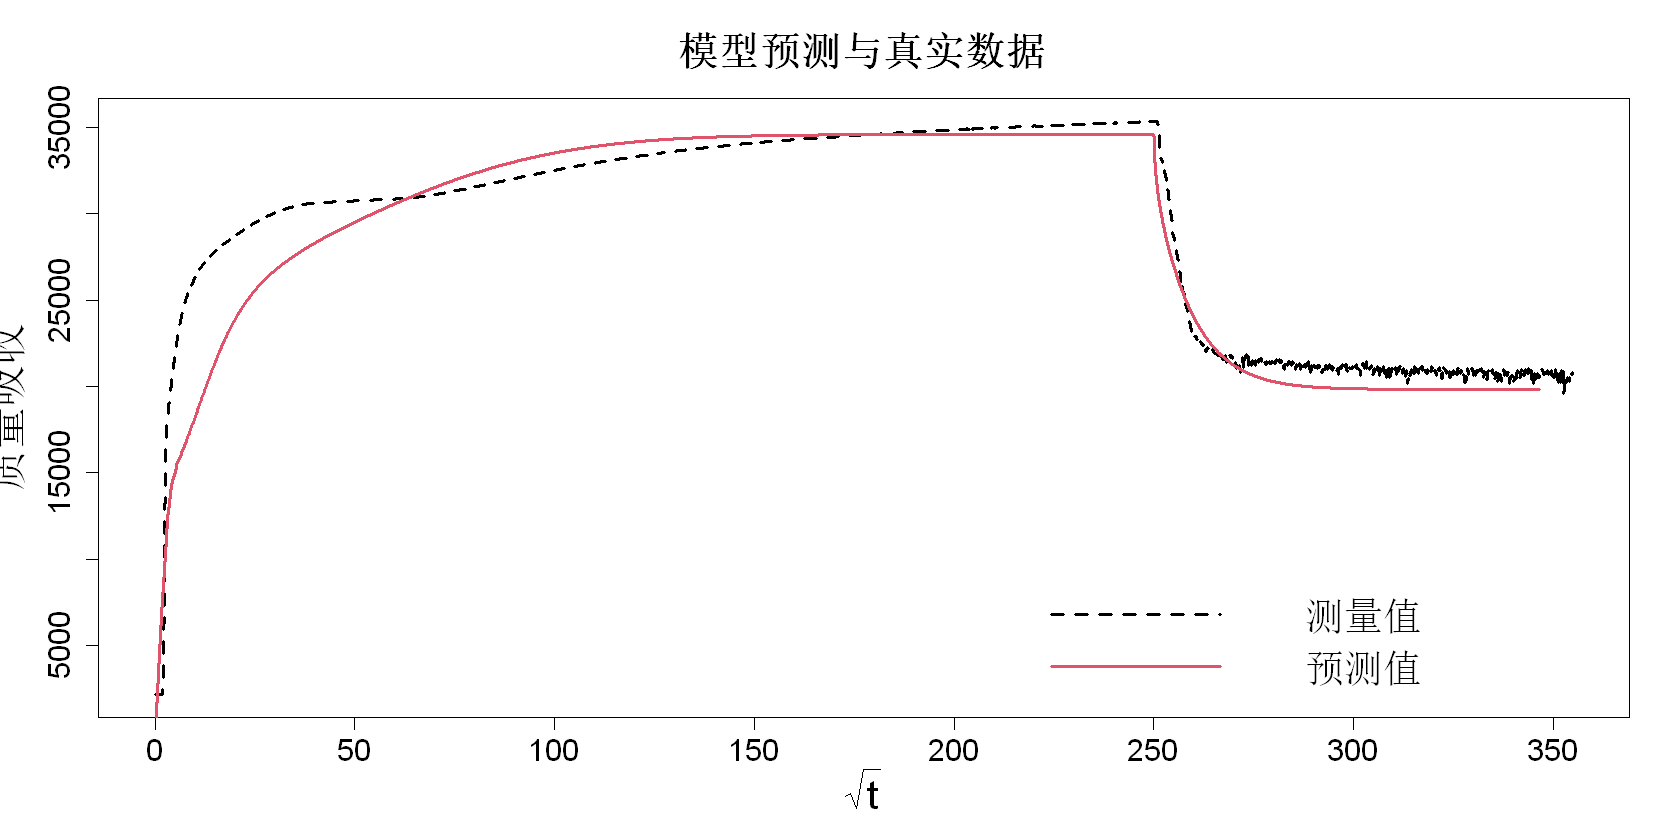

In [3]:
if(!file.exists("data/9.3-plot.RData")){
  best=read.table(file="data/txts/run51.txt")$V1
  pdet=c(seq(0,5000,length=2001),seq(5000,120000,length=4601)[-1])
  sorp=read.csv(file="data/exp_sorption_130c_8.7torr_483nm.csv")
  desorp=read.csv(file="data/exp_desorption_130c_8.7torr_483nm.csv")
  correct=35358.89275-34644.0896-1
  yexp=c(sorp[,2],desorp[,2]+correct)
  texp=c(sorp[,1]^2,desorp[,1]^2+62973)
  save(best,pdet,yexp,texp,file="data/9.3-plot.RData")
} else {
  load("data/9.3-plot.RData")
}
plot(sqrt(texp),yexp,main="模型预测与真实数据",cex.main=2,xlab=expression(sqrt(t)),ylab="质量吸收",lwd=3,cex.lab=2,cex.axis=1.5,type="l",lty=2)
lines(sqrt(pdet),best,col=2,lwd=3)
legend("bottomright",legend=c("测量值","预测值"),col=c(1,2),lty=c(2,1),bty="n",cex=2,lwd=c(3,3))


> **图 9.4**：双因子指数模型的八组稳健设计。蓝色实心圆点为基于局部 D‑最优设计采用重要支撑点得到的试验点，该类试验点对参数不确定性具备稳健性。红色叉号为采用序列最大投影方法得到的试验点，可抵御模型不确定性带来的影响。

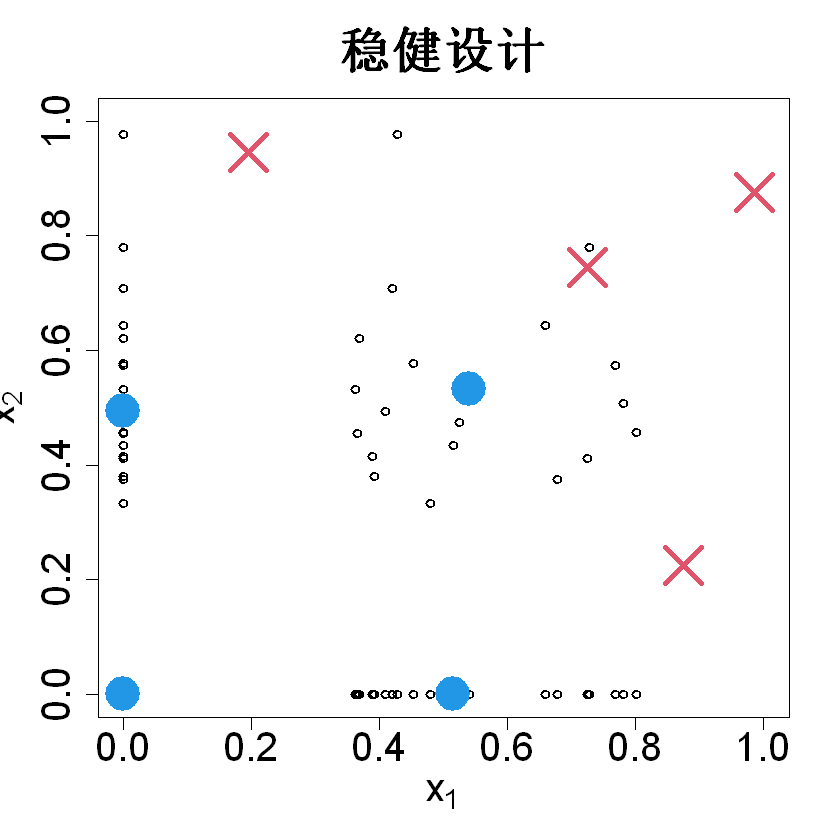

In [4]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/9.4-plot.RData")){
  library(support)
  sp.sample=function(x,n,prob,tol=1e-6,iter.max=10){
    # support points resampling
    if(is.null(dim(x)))stop("x must be a matrix!")
    N=nrow(x)
    x.dist=as.matrix(dist(x))
    x.measure=c(x.dist %*% prob)
    idx=c(which.min(x.measure))
    if(prob[idx[1]]<1/N)idx[1]=which.max(prob)
    for(i in 2:n){
      measure=x.measure-apply(matrix(x.dist[,idx],ncol=(i-1)),1,sum)/i
      idx=c(idx,which.min(measure))
    }
    edist=2*sum(x.measure[idx])/n-sum(x.dist[idx,idx])/n^2
    iter=0
    while(TRUE){
      iter=iter+1
      for(i in 1:n){
        measure=x.measure-apply(x.dist[,idx[-i]],1,sum)/n
        idx[i]=which.min(measure)
      }
      edist.new=2*sum(x.measure[idx])/n-sum(x.dist[idx,idx])/n^2
      if((edist-edist.new)<tol||iter>iter.max){
        break
      } else {
        edist=edist.new
      }
    }
    return(idx)
  }
  N=20;p=2
  samp=sp(n=N,p=2,dist.str=c("uniform","normal"))$sp
  samp[,1]=1+2*samp[,1]
  samp[,2]=2+1/2*samp[,2]
  D=NULL
  for(i in 1:20){
    D=rbind(D,matrix(c(0,0,1/samp[i,1],0,0,1/samp[i,2],1/samp[i,1],1/samp[i,2]),ncol=2,byrow=TRUE))
  }
  ind=sp.sample(D,4,prob=rep(.25/20,80))
  library(MaxPro)
  cand=MaxProLHD(100,2)$Design
  a=MaxProAugment(ExistDesign=D[ind,],CandDesign=cand,nNew=4)
  Dnew=a$Design[5:8,]
  save(D,ind,Dnew,file="data/9.4-plot.RData")
}
load("data/9.4-plot.RData")
options(repr.plot.width=7,repr.plot.height=7)
plot(D,xlim=c(0,1),ylim=c(0,1),main="稳健设计",cex.main=2.5,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,lwd=2)
points(D[ind,],pch=16,col=4,cex=4)
points(Dnew,col=2,pch=4,cex=4,lwd=4)